# 1. Business Understanding
---
El objetivo del proyecto es clasificar automáticamente los tipos de ataques y sus categorías utilizando descripciones técnicas y vulnerabilidades.

**Requisitos Funcionales:** Clasificación, identificación de categorías, análisis de vulnerabilidades, visualización, filtrado y predicción.

# 2. Data Understanding (EDA)
---
En esta etapa exploramos la estructura del dataset y las relaciones entre variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wordcloud
from wordcloud import WordCloud
%matplotlib inline

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

Importamos dataset

In [2]:
df = pd.read_csv('Attack_Dataset.csv', sep=",")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    14133 non-null  int64 
 1   Title                 14133 non-null  object
 2   Category              14133 non-null  object
 3   Attack Type           14133 non-null  object
 4   Scenario Description  14133 non-null  object
 5   Tools Used            14119 non-null  object
 6   Attack Steps          14133 non-null  object
 7   Target Type           14129 non-null  object
 8   Vulnerability         14115 non-null  object
 9   MITRE Technique       14109 non-null  object
 10  Impact                14130 non-null  object
 11  Detection Method      14129 non-null  object
 12  Solution              14130 non-null  object
 13  Tags                  14130 non-null  object
 14  Source                13973 non-null  object
 15  Unnamed: 15           46 non-null   

El dataset contiene 14.133 registros y 16 variables

## 2.1 Análisis Estadístico y Visual
Se analizan las categorías, objetivos y la relación entre variables.

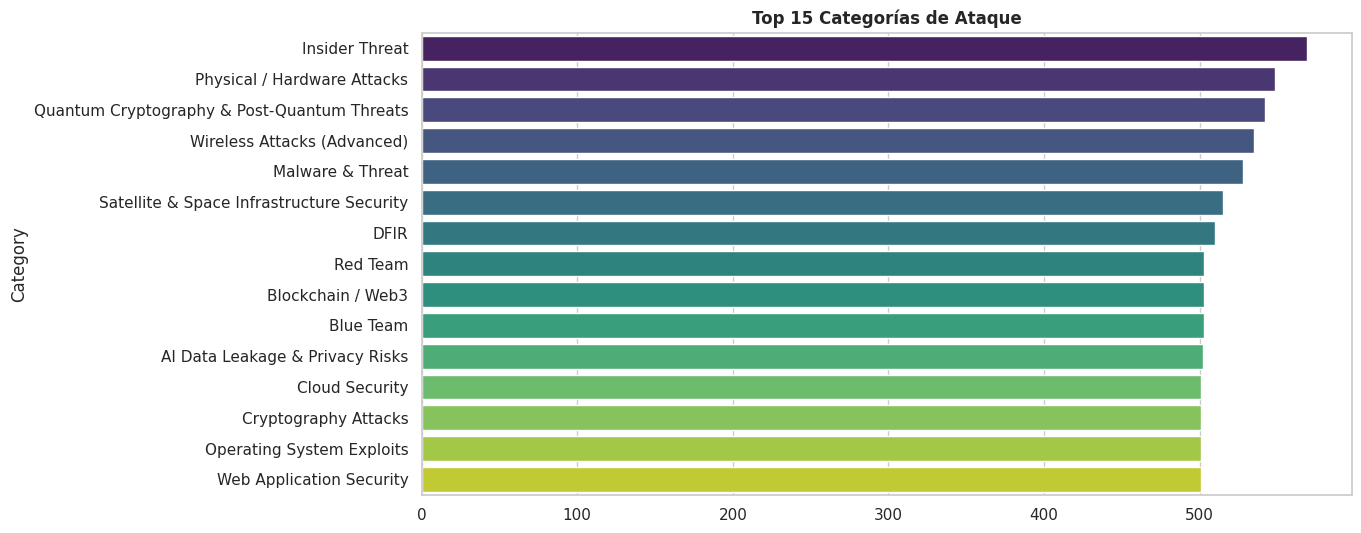

In [3]:
# Figura: Top Categorías
plt.figure(figsize=(12, 6))
top_categories = df['Category'].value_counts().head(15)
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette="viridis", legend=False)
plt.title('Top 15 Categorías de Ataque', fontweight='bold')
plt.show()

In [4]:
# Matriz de Co-ocurrencia
top_cat_heatmap = df['Category'].value_counts().head(10).index
top_att_heatmap = df['Attack Type'].value_counts().head(10).index
filtered_heat = df[(df['Category'].isin(top_cat_heatmap)) & (df['Attack Type'].isin(top_att_heatmap))]

pd.crosstab(filtered_heat['Category'], filtered_heat['Attack Type'], margins=True).style.background_gradient(cmap="Blues")

Attack Type,Data Exfiltration,Hardware Interface Exploitation,Misuse of Legitimate Tools,Privilege Escalation,Removable Media Attack,Wireless Attacks (Advanced),All
Category,,,,,,,
Blue Team,8,0,0,3,0,0,11
DFIR,0,0,0,1,0,0,1
Insider Threat,37,0,55,45,0,0,137
Physical / Hardware Attacks,0,161,0,0,55,0,216
Quantum Cryptography & Post-Quantum Threats,0,0,0,0,0,95,95
Red Team,0,0,0,2,0,0,2
All,45,161,55,51,55,95,462


Se observa una alta correlación entre 'Category' y 'Attack Type', lo que valida la viabilidad de un modelo supervisado.

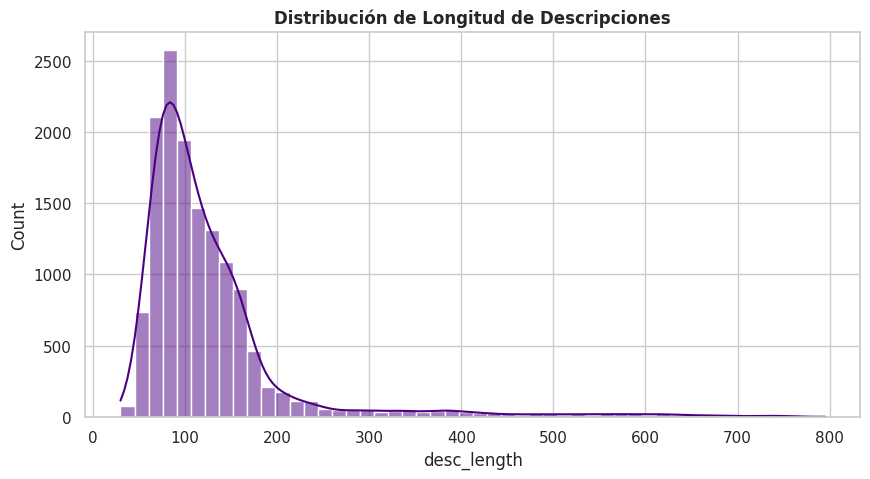

In [5]:
df['desc_length'] = df['Scenario Description'].fillna('').apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(df['desc_length'], bins=50, kde=True, color='indigo')
plt.title('Distribución de Longitud de Descripciones', fontweight='bold')
plt.show()

# 3. Data Preparation
---
Se identificaron valores nulos en múltiples variables como Vulnerability (18) y MITRE Technique (24).

La columna Unnamed: 15 corresponde a una variable basura, por lo que será eliminada.
En 'Attack Steps ' se observa un espacio que será eliminado.
Imputación de valores faltantes

In [6]:
df.drop(columns=['Unnamed: 15'], inplace=True, errors='ignore')
df.columns = df.columns.str.strip()

X_features_cols = ['Title', 'Scenario Description', 'Vulnerability', 'MITRE Technique']
df[X_features_cols] = df[X_features_cols].fillna('None')

Transformamos el texto a minúscula evitando la duplicidad de palabras.

In [7]:
# Creación de la variable combinada
df['X_combined'] = (df['Title'] + " " + df['Scenario Description'] + " " +
                    df['Vulnerability'] + " " + df['MITRE Technique']).str.lower()

Existe un **desbalanceo de clases:** algunos tipos de ataques cuentan con una sola ocurrencia, por lo que no podrán utilizarse tras la división del dataset. Por lo tanto, se considerarán clases válidas únicamente aquellas con al menos dos instancias.

In [8]:
# Manejo de Desbalanceo
counts = df['Attack Type'].value_counts()
clases_validas = counts[counts >= 2].index
df = df[df['Attack Type'].isin(clases_validas)].copy()

In [9]:
print(f"Registros tras limpieza: {df.shape[0]}")

Registros tras limpieza: 6159


# 4. Modelling
---

Se realiza la división de datos: Train 80% / Test 20%

In [10]:
# Definición de X e y
X = df['X_combined']
y = df['Attack Type']


Determinamos la variable Target [x]: Attack Type<br>
Determinamos la variable Features [y]: Title, Scenario Description, Vulnerability y MITRE Technique

# 5. Evaluation
---
Verificación de métricas y explicabilidad.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# VECTORIZE (TF-IDF)

vectorizer = TfidfVectorizer(max_features=1000)

X_tfidf = vectorizer.fit_transform(X)

# SPLIT TRAIN / TEST

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# MODELOS

rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000)
kmeans = KMeans(n_clusters=len(y.unique()), random_state=42)

# ENTRENAMIENTO

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

# KMeans (no supervisado)
kmeans.fit(X_train)

# 5. PREDICCIONES

y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)

In [21]:

# EVALUACIÓN

print("=== RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


=== RANDOM FOREST ===
Accuracy: 0.5202922077922078
                                                          precision    recall  f1-score   support

                                               API Abuse       0.17      0.33      0.22         3
                                         API Token Theft       1.00      1.00      1.00         1
                     Abusing Email Auto-forwarding Rules       0.44      1.00      0.62         4
                                   Acceleration Spoofing       0.00      0.00      0.00         1
                                   Acoustic Side-Channel       0.00      0.00      0.00         1
                            Acoustic Side-Channel Attack       0.00      0.00      0.00         2
                         Adversarial Example (White-box)       1.00      1.00      1.00         1
                                       Anomaly Detection       0.00      0.00      0.00         1
                                    Anti-Sandbox Evasion       0.5

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [22]:

print("\n=== LOGISTIC REGRESSION ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


=== LOGISTIC REGRESSION ===
Accuracy: 0.38961038961038963
                                                          precision    recall  f1-score   support

                                               API Abuse       0.00      0.00      0.00         3
                                         API Token Theft       0.00      0.00      0.00         1
                     Abusing Email Auto-forwarding Rules       0.67      1.00      0.80         4
                                   Acceleration Spoofing       0.00      0.00      0.00         1
                                   Acoustic Side-Channel       0.00      0.00      0.00         1
                            Acoustic Side-Channel Attack       0.00      0.00      0.00         2
                         Adversarial Example (White-box)       0.00      0.00      0.00         1
                                       Anomaly Detection       0.00      0.00      0.00         1
                                    Anti-Sandbox Evasion  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [29]:
from sklearn.metrics import f1_score

f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"F1-score RF: {f1_rf:.2f}")

f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
print(f"F1-score LR: {f1_lr:.2f}")

F1-score RF: 0.47
F1-score LR: 0.31
